# PART A: Regression on California test scores

##### 1. Find the url for the California Test Score Data Set from the following website: https://vincentarelbundock.github.io/Rdatasets/datasets.html. Read through the "DOC" file to understand the variables in the dataset, then use the following url to import the data: https://vincentarelbundock.github.io/Rdatasets/csv/Ecdat/Caschool.csv. The target data (i.e. the dependent variable) is named "testscr". You can use all variables in the data except for "readscr" and "mathscr" in the following analysis (those two variables were used to generate the dependent variable).


In [187]:
# Import Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CASchools (California Test Score) dataset
caschools = pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/Ecdat/Caschool.csv")
caschools.head()

# Description: The dataset contains data on test performance, school characteristics and
# student demographic backgrounds for school districts in California. Target data = caschools['testscr']

,rownames,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024


##### 2. Pick 3 continuous variables from the data that you think are likely to have a relationship with the target feature. Visualize the univariate distribution of the target feature and each of these three explanatory variables.   

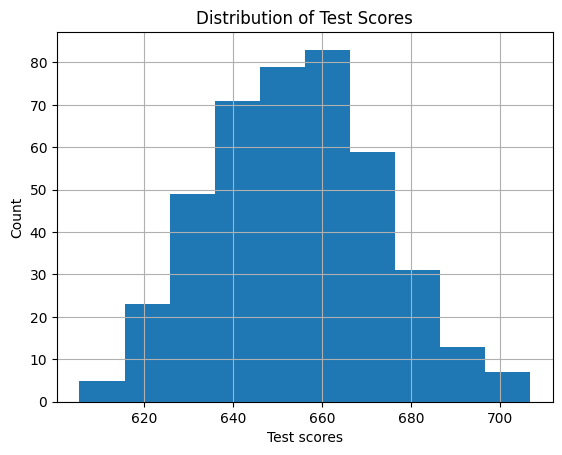

In [188]:
# I picked the continuous variables income, expenditure, and english.
# I used histograms to visualize the univariate distribution of the target feature and three explanatory variables.

# Histogram Test scores
caschools['testscr'].hist()
plt.title('Distribution of Test Scores')
plt.xlabel('Test scores')
plt.ylabel('Count')
plt.show()

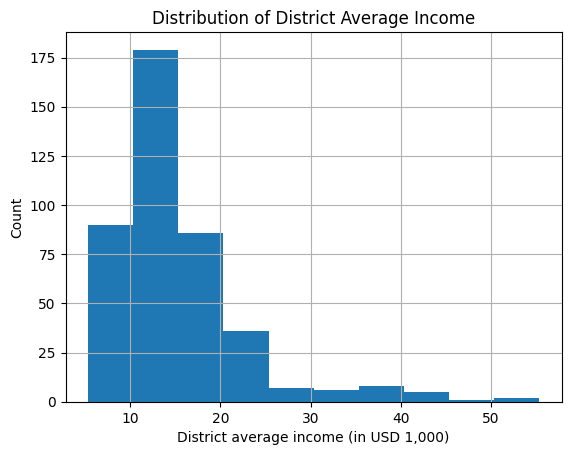

In [ ]:
# The district average income (in USD 1,000) relates to socio-economic status,
# which is strongly related to academic performance.

# Histogram District average income
caschools['avginc'].hist()
plt.title('Distribution of District Average Income')
plt.xlabel('District average income (in USD 1,000)')
plt.ylabel('Count')
plt.show()

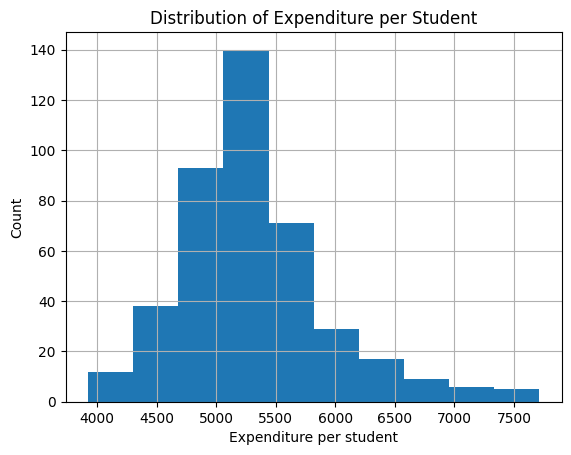

In [ ]:
# The expenditure per student reflects school resources,
# which may affect student academic performance.

# Histogram Expenditure per student
caschools['expnstu'].hist()
plt.title('Distribution of Expenditure per Student')
plt.xlabel('Expenditure per student')
plt.ylabel('Count')
plt.show()

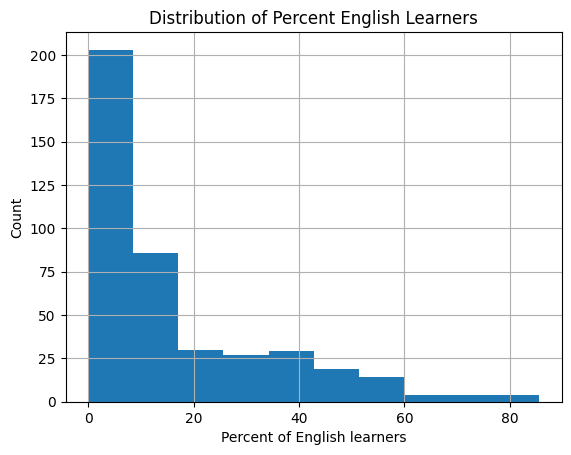

In [ ]:
# The percent of English learners may affect average test performance.

# Histogram Percent of English learners
caschools['elpct'].hist()
plt.title('Distribution of Percent English Learners')
plt.xlabel('Percent of English learners')
plt.ylabel('Count')
plt.show()

##### 3. Visualize the dependency of the target on each feature you just plotted.


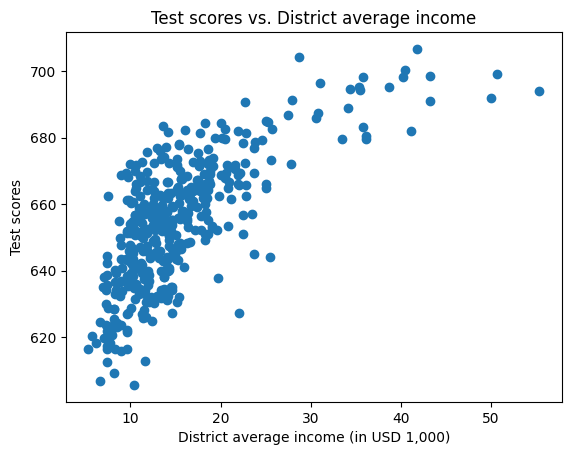

In [ ]:
# I used scatterplots to visualize the dependency of the target on each feature I just plotted.

# Scatterplot Test scores vs. District average income
plt.scatter(caschools['avginc'], caschools['testscr'])
plt.title('Test scores vs. District average income')
plt.xlabel('District average income (in USD 1,000)')
plt.ylabel('Test scores')
plt.show()

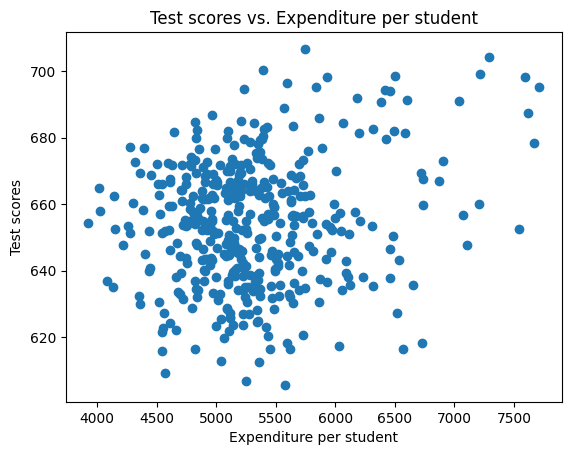

In [ ]:
# Scatterplot Test scores vs. Expenditure per student
plt.scatter(caschools['expnstu'], caschools['testscr'])
plt.title('Test scores vs. Expenditure per student')
plt.xlabel('Expenditure per student')
plt.ylabel('Test scores')
plt.show()

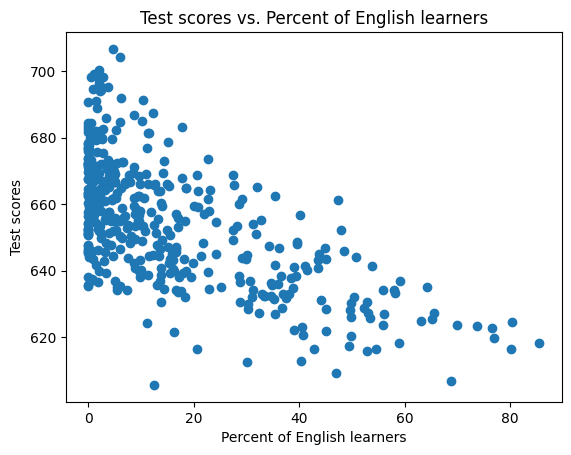

In [ ]:
# Scatterplot Test scores vs. Percent of English learners
plt.scatter(caschools['elpct'], caschools['testscr'])
plt.title('Test scores vs. Percent of English learners')
plt.xlabel('Percent of English learners')
plt.ylabel('Test scores')
plt.show()

##### 4. Build a KNN Regression model that evaluates the relationship between the target variable and all of the quantitative features (enrltot, teachers, calwpct, mealpct, computer, compstu, expnstu, str, avginc, & elpct). Make sure that you first split the data into training and test sets and tune the hyperparameters where possible using GridSearchCV. Run one version with StandardScaler and one version without it.

In [189]:
### KNN Regression without StandardScaler

# Change variable names to X, y to prepare for train/test split
Xcolumns = ['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

y = caschools['testscr']
X = caschools[Xcolumns]

from sklearn.model_selection import train_test_split

# Use train_test_split(X,y) to create four new data sets, defaults to .75/.25 split
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X.shape)
X_train.shape

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for

param_grid = {'n_neighbors': np.arange(1, 15, 2)} #np.arange creates sequence of numbers for each k value

grid = GridSearchCV(KNeighborsRegressor(), param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("KNN Regression without Standard Scaler")
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
print("test-set score: {:.3f}".format(grid.score(X_test, y_test)))


### KNN Regression with StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsRegressor())])

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for

param_grid = {'knn__n_neighbors': np.arange(1, 15, 2)} #np.arange creates sequence of numbers for each k value

grid = GridSearchCV(pipe, param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("\nKNN Regression with Standard Scaler")
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
print("test-set score: {:.3f}".format(grid.score(X_test, y_test)))

(420, 10)
KNN Regression without Standard Scaler
best mean cross-validation score: 0.024
best parameters: {'n_neighbors': np.int64(11)}
test-set score: 0.015

KNN Regression with Standard Scaler
best mean cross-validation score: 0.767
best parameters: {'knn__n_neighbors': np.int64(11)}
test-set score: 0.674


##### 5. Repeat Question 4 three more times, each time using one of the linear models that we have learned for regression: Linear Regression (without regularization), Ridge Regression, & Lasso Regression.




In [ ]:
### Linear Regression (No Regularization) without StandardScaler

from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y)

lr = LinearRegression()
lr.fit(X_train, y_train)

# The “slope” parameters (w), also called weights or coefficients, are stored in the coef_
# attribute, while the offset or intercept (b) is stored in the intercept_ attribute:

print("Linear Regression without Standard Scaler")
print(Xcolumns)  #column names to help identify output
print("\nlr.coef_: "+str(lr.coef_))
print("\nlr.intercept_: {}".format(lr.intercept_))
print("Training set score: {:.3f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.3f}".format(lr.score(X_test, y_test)))

### Linear Regression (No Regularization) with StandardScaler

pipe_lr = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
pipe_lr.fit(X_train, y_train)

# The “slope” parameters (w), also called weights or coefficients, are stored in the coef_
# attribute, while the offset or intercept (b) is stored in the intercept_ attribute:

print("\nLinear Regression with Standard Scaler")
print(Xcolumns)
print("\nCoefficients:", pipe_lr.named_steps["lr"].coef_)
print("Intercept:", pipe_lr.named_steps["lr"].intercept_)
print("Training set score: {:.3f}".format(pipe_lr.score(X_train, y_train)))
print("Test set score: {:.3f}".format(pipe_lr.score(X_test, y_test)))


Linear Regression without Standard Scaler
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

lr.coef_: [-1.19357117e-03  2.37991268e-02 -7.61003497e-02 -3.68970746e-01
  4.81497567e-05  1.63826504e+01  1.54601720e-03  4.54656189e-02
  6.88858182e-01 -2.08348916e-01]

lr.intercept_: 653.1153322314186
Training set score: 0.813
Test set score: 0.789

Linear Regression with Standard Scaler
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

Coefficients: [ -5.02666514   4.81658115  -0.89878484 -10.16227254   0.02253439
   1.04258963   0.99986133   0.088462     4.86565347  -3.90843806]
Intercept: 653.668097795759
Training set score: 0.813
Test set score: 0.789


In [ ]:
### Ridge Regression without StandardScaler

from sklearn.linear_model import Ridge

param_grid_ridge = {"alpha": np.logspace(-3, 3, 50)} # This range covers very light to very strong regularization.
grid_ridge = GridSearchCV(Ridge(), param_grid=param_grid_ridge, cv=10)
grid_ridge.fit(X_train, y_train)

print("Ridge Regression without Standard Scaler")
print("Best alpha:", grid_ridge.best_params_)
print("Training set score: {:.3f}".format(grid_ridge.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_ridge.score(X_test, y_test)))

ridge_unscaled = grid_ridge.best_estimator_

print(Xcolumns)
print("\nridge.coef_: {}".format(ridge_unscaled.coef_))
print("\nridge.intercept_: {}".format(ridge_unscaled.intercept_))

### Ridge Regression with StandardScaler

pipe_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])

param_grid_ridge_scaled = {"ridge__alpha": np.logspace(-3, 3, 50)}
grid_ridge_scaled = GridSearchCV(pipe_ridge, param_grid=param_grid_ridge_scaled, cv=10)
grid_ridge_scaled.fit(X_train, y_train)

print("\nRidge Regression with Standard Scaler")
print("Best alpha:", grid_ridge_scaled.best_params_)
print("Training set score: {:.3f}".format(grid_ridge_scaled.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_ridge_scaled.score(X_test, y_test)))

ridge_scaled = grid_ridge_scaled.best_estimator_.named_steps["ridge"]

print(Xcolumns)
print("\nridge.coef_: {}".format(ridge_scaled.coef_))
print("\nridge.intercept_: {}".format(ridge_scaled.intercept_))

Ridge Regression without Standard Scaler
Best alpha: {'alpha': np.float64(1000.0)}
Training set score: 0.810
Test set score: 0.798
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

ridge.coef_: [-0.00111547  0.01575538 -0.09175796 -0.37882706  0.00289081  0.01460314
  0.00206445 -0.0244993   0.60524496 -0.21115992]

ridge.intercept_: 655.8910036273289

Ridge Regression with Standard Scaler
Best alpha: {'ridge__alpha': np.float64(14.563484775012444)}
Training set score: 0.812
Test set score: 0.792
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

ridge.coef_: [-0.46338689 -0.03930893 -1.48628409 -8.90845312  0.40786595  0.95564478
  0.91235723 -0.18645161  5.1118564  -4.25634322]

ridge.intercept_: 653.668097795759


In [ ]:
### Lasso Regression without StandardScaler

from sklearn.linear_model import Lasso

param_grid_lasso = {"alpha": np.logspace(-4, 1, 50)} # This range covers very light to very strong regularization.
grid_lasso = GridSearchCV(Lasso(max_iter=10000, random_state=42), param_grid=param_grid_lasso, cv=10)
grid_lasso.fit(X_train, y_train)

print("Lasso Regression without Standard Scaler")
print("Best alpha:", grid_lasso.best_params_)
print("Training set score: {:.3f}".format(grid_lasso.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_lasso.score(X_test, y_test)))

lasso_unscaled = grid_lasso.best_estimator_
print(Xcolumns)
print("\nlasso.coef_: {}".format(lasso_unscaled.coef_))
print("\nlasso.intercept_: {}".format(lasso_unscaled.intercept_))
print("Number of features used: {}".format(np.sum(lasso_unscaled.coef_ != 0)))

### Lasso Regression with StandardScaler

pipe_lasso = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(max_iter=10000, random_state=42))])

param_grid_lasso_scaled = {"lasso__alpha": np.logspace(-4, 1, 50)}
grid_lasso_scaled = GridSearchCV(pipe_lasso, param_grid=param_grid_lasso_scaled, cv=10)
grid_lasso_scaled.fit(X_train, y_train)

print("\nLasso Regression with Standard Scaler")
print("Best alpha:", grid_lasso_scaled.best_params_)
print("Training set score: {:.3f}".format(grid_lasso_scaled.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_lasso_scaled.score(X_test, y_test)))

lasso_scaled = grid_lasso_scaled.best_estimator_.named_steps["lasso"]
print(Xcolumns)
print("\nlasso.coef_: {}".format(lasso_scaled.coef_))
print("\nlasso.intercept_: {}".format(lasso_scaled.intercept_))
print("Number of features used: {}".format(np.sum(lasso_scaled.coef_ != 0)))

Lasso Regression without Standard Scaler
Best alpha: {'alpha': np.float64(0.5963623316594643)}
Training set score: 0.811
Test set score: 0.795
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

lasso.coef_: [-0.00089497  0.01086972 -0.08129292 -0.37135878  0.00287052  0.
  0.00192097 -0.          0.66783591 -0.21274136]

lasso.intercept_: 654.820745822366
Number of features used: 8

Lasso Regression with Standard Scaler
Best alpha: {'lasso__alpha': np.float64(0.07196856730011521)}
Training set score: 0.812
Test set score: 0.791
['enrltot', 'teachers', 'calwpct', 'mealpct', 'computer', 'compstu', 'expnstu', 'str', 'avginc', 'elpct']

lasso.coef_: [ -0.12245506  -0.          -0.77249526 -10.19459236  -0.
   1.01672585   0.87695403  -0.10839973   4.92331073  -3.85110105]

lasso.intercept_: 653.668097795759
Number of features used: 8


##### 6. How different are the results of your 4 models? What impact does StandardScalar make? Discuss which final model you would choose to predict new data & why.


Across the four models, KNN, Linear Regression, Ridge, and Lasso, the results show clear patterns in predictive performance. The three linear models (OLS, Ridge, and Lasso) produce very similar results, with training and test R^2 values generally falling in the range of approximately 0.79 to 0.82. This indicates that the relationship between the predictors and test scores is largely linear and can be well captured by a standard regression framework. Regularization through Ridge or Lasso provides only modest improvements in test performance, suggesting that the dataset does not suffer heavily from overfitting or severe multicollinearity.

The impact of StandardScaler differs across models. For Linear Regression, scaling does not change predictive performance, as OLS is scale-invariant: standardizing predictors alters coefficient magnitudes but not fitted values. For Ridge and Lasso, scaling changes the magnitude of the selected tuning parameter because the penalty depends on coefficient size, which is influenced by feature scale. However, predictive performance changes only slightly, typically by a few thousandths in R^2, indicating that scaling improves regularization fairness and numerical stability rather than dramatically improving accuracy.

KNN, by contrast, is highly sensitive to scaling. Without standardization, KNN performs very poorly because distance calculations are dominated by variables measured on larger scales. After applying StandardScaler, predictive performance increases substantially to the 0.60-0.75 range. Nevertheless, even after scaling, KNN’s test performance remains slightly below that of the linear models. This indicates that the structure of the data is better captured by a linear model than by a purely distance-based method.

Given these results, I would choose Ridge Regression with StandardScaler as the final model for predicting new data. It achieves test R^2 values around 0.80, slightly higher than or comparable to the other linear models, while incorporating regularization that improves stability and reduces variance. Since Ridge and Lasso yield similar cross-validated performance and there is no strong evidence that only a small number of predictors drive the outcome, Ridge is preferable because it stabilizes correlated predictors without eliminating them entirely. Because the predictors are likely correlated, Ridge’s L2 penalty is well suited to this setting. Overall, Ridge with scaling provides a strong balance between bias and variance while maintaining interpretability and robust predictive performance.

##### 7. Compare the coefficients of your two best linear models (not KNN). Do they agree on which features are important?

To compare the two best linear models, I focus on Ridge Regression with StandardScaler and Lasso Regression with StandardScaler, since these slightly outperformed the other specifications in test performance. Examining the scaled coefficients allows for meaningful comparison because all predictors are measured in standardized units.

Both models largely agree on which features are most important. In particular, mealpct, avginc, and elpct have the largest coefficients in absolute value in both models. The percentage of students receiving subsidized meals (mealpct) has a large negative coefficient in both cases, suggesting that higher economic disadvantage is strongly associated with lower test scores. Similarly, average income (avginc) has a large positive coefficient, indicating that higher district income is strongly associated with better performance. The percentage of English learners (elpct) also shows a sizable negative effect in both models. The student-teacher ratio (str) and CalWORKs percentage (calwpct) also appear consistently negative and relatively important.

The main difference between the two models is that Lasso performs variable selection. In the scaled Lasso model, three predictors (enrltot, teachers, and computer) are shrunk exactly to zero, reducing the number of active features from ten to seven. Ridge, in contrast, retains all predictors but shrinks their magnitudes toward zero. Despite this difference, both models identify the same core socioeconomic and demographic variables as the primary drivers of test scores.

Overall, the two models agree on which features are most important, particularly measures related to economic disadvantage and income. The differences lie primarily in the treatment of smaller-effect predictors, with Lasso eliminating some variables entirely and Ridge retaining them in a shrunk form.


# PART B: Classification on red and white wine characteristics

##### 1. First, import the red and the white wine csv files into separate pandas dataframes from the following website. Note that you’ll need to adjust the argument for read_csv() from sep=',' to sep=';' (https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv.) (https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv.)


In [ ]:
# Load white wine dataset
whitewine = pd.read_csv(
"https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=';')
print("White wine shape:", whitewine.shape)
whitewine.head()

White wine shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
# Load red wine dataset
redwine = pd.read_csv(
"https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
print("Red wine shape:", redwine.shape)
redwine.head()

Red wine shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


##### 2. Add a new column to each dataframe called "winetype". For the white wine dataset, label the values in this column with a 0, indicating white wine. For the red wine dataset, label values with a 1, indicating red wine. Combine both datasets into a single dataframe. The target data (i.e. the dependent variable) is "winetype".


In [ ]:
# Create new columns based on the values in other columns.

whitewine['winetype'] = 0
redwine['winetype'] = 1

wine = pd.concat([redwine, whitewine])
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,winetype
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


##### 3. Pick 3 continuous variables from the data that you think are likely to have a relationship with the target feature. Visualize the univariate distribution of the target feature and each of these three explanatory variables.  

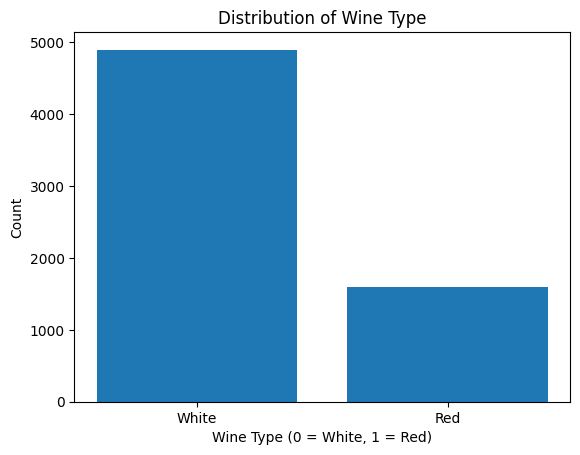

In [ ]:
# I picked the continuous variables alcohol, volatile acidity, and density.

# I used a bar chart to visualize the univariate distribution of the target feature because it is a binary variable, and histograms to visualize each of the three explanatory variables.

# Bar chart of Target Variable (Wine Type)
# Create labels and counts
wine_types = ["White", "Red"]
counts = wine['winetype'].value_counts().sort_index().values
# Bar chart
plt.bar(wine_types, counts)
plt.title("Distribution of Wine Type")
plt.xlabel('Wine Type (0 = White, 1 = Red)')
plt.ylabel("Count")
plt.show()

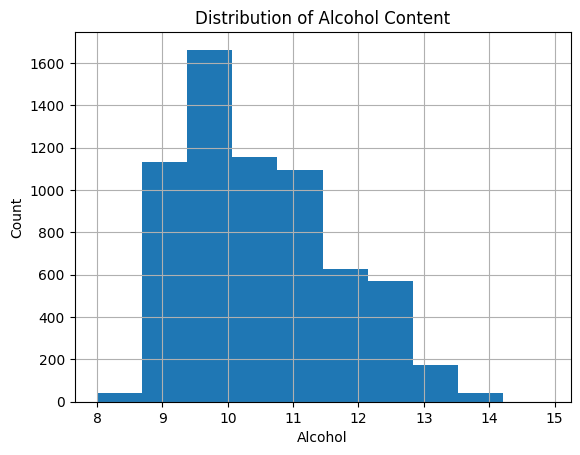

In [ ]:
# Alcohol content may differ between red and white wines due to differences in fermentation.

# Histogram of Alcohol
wine['alcohol'].hist()
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()


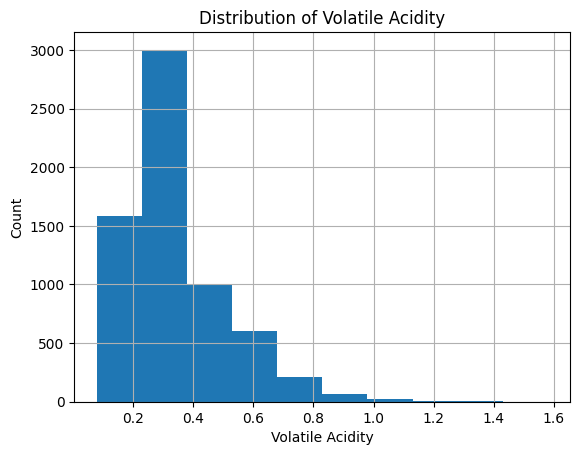

In [ ]:
# Volatile acidity reflects acidity levels, which can vary by wine type.

# Histogram of Volatile Acidity
wine['volatile acidity'].hist()
plt.title('Distribution of Volatile Acidity')
plt.xlabel('Volatile Acidity')
plt.ylabel('Count')
plt.show()

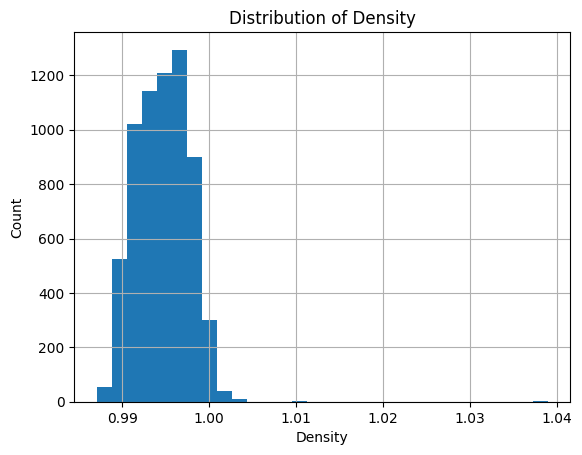

In [ ]:
# Density is related to sugar and alcohol content, which may systematically differ
# between red and white wines.

# Histogram of Density
wine['density'].hist(bins=30)
plt.title('Distribution of Density')
plt.xlabel('Density')
plt.ylabel('Count')
plt.show()

##### 4. Build a KNN Classification model that evaluates the relationship between the target variable and the 3 features you selected in Question 3. Make sure that you first split the data into training and test sets and tune the hyperparameters where possible using GridSearchCV. Run one version with StandardScaler and one version without it.

In [191]:
### KNN Classification without StandardScaler

# Change variable names to X, y to prepare for train/test split

Xcolumns = ['alcohol', 'volatile acidity', 'density']

y = wine['winetype']
X = wine[Xcolumns]

# use train_test_split(X,y) to create four new data sets, defaults to .75/.25 split
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X.shape)
X_train.shape

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for

param_grid = {'n_neighbors': np.arange(1, 21, 2)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("KNN Classification without Standard Scaler")
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
print("test-set score: {:.3f}".format(grid.score(X_test, y_test)))


### KNN Classification with StandardScaler

pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for

param_grid = {'knn__n_neighbors': np.arange(1, 21, 2)} #np.arange creates sequence of numbers for each k value

grid = GridSearchCV(pipe, param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("\nKNN Classification with Standard Scaler")
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
print("test-set score: {:.3f}".format(grid.score(X_test, y_test)))

(6497, 3)
KNN Classification without Standard Scaler
best mean cross-validation score: 0.873
best parameters: {'n_neighbors': np.int64(17)}
test-set score: 0.879

KNN Classification with Standard Scaler
best mean cross-validation score: 0.921
best parameters: {'knn__n_neighbors': np.int64(9)}
test-set score: 0.925


##### 5. Repeat Question 4 two more times, each time using a different linear model that we have learned for classification: Logistic Regression with no regularization, and Logistic Regression with L2 regularization.


In [192]:
### Logistic Regression without StandardScaler

from sklearn.linear_model import LogisticRegression

# random_state ensures same data will be generated for example each time
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Set penalty to none since we are starting with non penalized logit, L1 and L2 are other options
log = LogisticRegression(penalty=None, max_iter=10000).fit(X_train, y_train)

print("Logistic Regression (No Regularization) without Standard Scaler")
print(Xcolumns)
print("\nlog.coef_: " + str(log.coef_))
print("\nlog.intercept_: {}".format(log.intercept_))
print("Training set score: {:.3f}".format(log.score(X_train, y_train)))
print("Test set score: {:.3f}".format(log.score(X_test, y_test)))

### Logistic Regression (No Regularization) with StandardScaler

pipe_log = Pipeline([("scaler", StandardScaler()), ("log", LogisticRegression(penalty=None, max_iter=10000))])
pipe_log.fit(X_train, y_train)

print("\nLogistic Regression (No Regularization) with Standard Scaler")
print(Xcolumns)
print("\nlog.coef_: " + str(pipe_log.named_steps["log"].coef_))
print("\nlog.intercept_: {}".format(pipe_log.named_steps["log"].intercept_))
print("Training set score: {:.3f}".format(pipe_log.score(X_train, y_train)))
print("Test set score: {:.3f}".format(pipe_log.score(X_test, y_test)))

Logistic Regression (No Regularization) without Standard Scaler
['alcohol', 'volatile acidity', 'density']

log.coef_: [[  1.32637522  12.8277689  813.29915512]]

log.intercept_: [-829.48031835]
Training set score: 0.907
Test set score: 0.905

Logistic Regression (No Regularization) with Standard Scaler
['alcohol', 'volatile acidity', 'density']

log.coef_: [[1.58400604 2.07001759 2.45053421]]

log.intercept_: [-2.29328306]
Training set score: 0.907
Test set score: 0.904


In [ ]:
### Logistic Regression (L2 Regularization) without StandardScaler

# tune C (inverse of regularization strength) with GridSearchCV like you did for KNN.

param_grid_log_l2 = {"C": np.logspace(-3, 3, 25)}

grid_log_l2 = GridSearchCV(LogisticRegression(penalty="l2", max_iter=10000),
    param_grid=param_grid_log_l2, cv=10)

grid_log_l2.fit(X_train, y_train)

print("Logistic Regression (L2) without Standard Scaler")
print(Xcolumns)
print("Best C:", grid_log_l2.best_params_)
print("Training set score: {:.3f}".format(grid_log_l2.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_log_l2.score(X_test, y_test)))

log_l2 = grid_log_l2.best_estimator_
print("\nlog_l2.coef_: " + str(log_l2.coef_))
print("\nlog_l2.intercept_: {}".format(log_l2.intercept_))


### Logistic Regression (L2 regularization) with StandardScaler

pipe_log_l2 = Pipeline([("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", max_iter=10000))])

# we search over a wide range of C values (10^-3 to 10^3) on a logarithmic scale.
# C is the inverse of regularization strength: small C = strong regularization,
# large C = weak regularization. Using logspace allows us to efficiently explore
# several orders of magnitude and let cross-validation determine the optimal
# balance between bias and variance.
param_grid_log_l2_scaled = {"logreg__C": np.logspace(-3, 3, 25)}

grid_log_l2_scaled = GridSearchCV(pipe_log_l2,
    param_grid=param_grid_log_l2_scaled, cv=10)

grid_log_l2_scaled.fit(X_train, y_train)

print("\nLogistic Regression (L2) with Standard Scaler")
print(Xcolumns)
print("Best C:", grid_log_l2_scaled.best_params_)
print("Training set score: {:.3f}".format(grid_log_l2_scaled.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid_log_l2_scaled.score(X_test, y_test)))

log_l2_scaled = grid_log_l2_scaled.best_estimator_.named_steps["logreg"]
print("\nlog_l2.coef_: " + str(log_l2_scaled.coef_))
print("\nlog_l2.intercept_: {}".format(log_l2_scaled.intercept_))

Logistic Regression (L2) without Standard Scaler
['alcohol', 'volatile acidity', 'density']
Best C: {'C': np.float64(1000.0)}
Training set score: 0.898
Test set score: 0.895

log_l2.coef_: [[  0.69131886  11.88433282 427.89504492]]

log_l2.intercept_: [-438.71817908]

Logistic Regression (L2) with Standard Scaler
['alcohol', 'volatile acidity', 'density']
Best C: {'logreg__C': np.float64(0.5623413251903491)}
Training set score: 0.907
Test set score: 0.904

log_l2.coef_: [[1.52720968 2.03798138 2.37412698]]

log_l2.intercept_: [-2.25538291]


##### 6. How different are the results of your 3 models? What impact does StandardScalar make? Discuss which final model you would choose to predict new data & why.


Across the three models, KNN, Logistic Regression without regularization, and Logistic Regression with L2 regularization, the results show clear differences in performance and sensitivity to scaling.

KNN is the most sensitive to StandardScaler. Without scaling, its test accuracy is around 0.89, while after scaling it improves substantially to approximately 0.93. This improvement occurs because KNN relies on Euclidean distance. When features such as alcohol, volatile acidity, and density are measured on different scales, the variable with the largest magnitude dominates the distance calculation. Standardizing the predictors ensures that each feature contributes equally, leading to significantly better classification performance. The optimal number of neighbors also changes when scaling is applied, further illustrating that scaling materially affects the model.

Logistic Regression behaves differently. For the unregularized model, scaling does not meaningfully change test accuracy (remaining around 0.89-0.91), although it dramatically changes the magnitude of the coefficients. Without scaling, coefficients are very large in magnitude because density is measured on a much smaller numerical scale than the other variables. After scaling, the coefficients become more balanced and directly comparable in size. This improves interpretability but does not substantially affect predictive accuracy.

For Logistic Regression with L2 regularization, scaling has a moderate but noticeable impact. Without scaling, the best regularization parameter C is very large, implying weak regularization. With scaling, the optimal C becomes much smaller, and test accuracy improves slightly to around 0.904. This occurs because L2 regularization penalizes coefficient magnitude, and without scaling, the penalty is uneven across predictors. StandardScaler ensures that the regularization term treats all features fairly, leading to more stable coefficient estimates and slightly improved performance.

Comparing overall performance, the scaled KNN model achieves the highest test accuracy (around 0.91-0.93), outperforming both versions of Logistic Regression (around 0.89-0.91). Therefore, I would choose KNN with StandardScaler as the final model for predicting new data. It provides the strongest out-of-sample accuracy and benefits significantly from proper scaling. Although Logistic Regression offers greater interpretability, the primary objective here is predictive performance, and the scaled KNN model performs best in that regard.

##### 7. Compare the coefficients for Logistic Regression with and without regularization. Do they agree on which features are important?

When comparing Logistic Regression without regularization and Logistic Regression with L2 regularization, the two models largely agree on which features are important, although the magnitude of the coefficients differs.

Across both models, the signs of the coefficients are consistent. Alcohol has a slightly positive coefficient, while volatile acidity and density have large positive effects (when interpreted in the scaled version). This consistency in sign indicates that both models agree on the direction of the relationship between each predictor and the probability of being red versus white wine. Therefore, the same features are driving classification in both models.

However, the magnitude of the coefficients differs noticeably. In the unregularized model, the coefficients are much larger in absolute value, especially when the predictors are not scaled. In contrast, the L2-regularized model shrinks the coefficients toward zero. This shrinkage is the core purpose of L2 regularization: it penalizes large coefficient values to reduce variance and improve model stability. While the coefficients are smaller under regularization, their relative importance remains similar.

After scaling, the comparison becomes clearer. Both the unregularized and L2-regularized models show similar relative magnitudes across alcohol, volatile acidity, and density, suggesting agreement about which predictors contribute most strongly to classification. The key difference is that the regularized model produces more moderate and stable coefficient estimates.

Overall, the two models agree on which features are important and in which direction they influence classification. L2 regularization primarily affects coefficient magnitude rather than feature selection, improving stability without fundamentally changing the interpretation of the predictors.